[INFO] Module loaded: pyspark
[INFO] Module loaded: dask
[WARN] Module not available: tensorflow -> No module named 'tensorflow.python'
[INFO] Module loaded: torch
[INFO] Module loaded: spacy
[INFO] Module loaded: nltk
[INFO] Module loaded: networkx
[INFO] Module loaded: geopandas
[INFO] Module loaded: folium
[INFO] Module loaded: dash
[INFO] Module loaded: bokeh
[INFO] Module loaded: pytest
[INFO] Module loaded: great_expectations

[NOTES] Data Entry:
- Numeric data: Synthetic via NumPy (privacy-safe).
- Text data: Small synthetic incident report list for NLP.
- Geospatial data: Simple site coordinates for mapping.
- Database: SQLite in-memory via SQLAlchemy (simulates SQL Server ingestion).
[INFO] Data saved to SQLite in-memory database.

[NOTES] Analysis Steps:
- Pandas pivot -> Day/Shift heatmap.
- SciPy correlation -> checks relationship metrics.
- Scikit-learn -> simple regression models.
- Statsmodels -> OLS summary for transparency.
                            OLS Regression Re

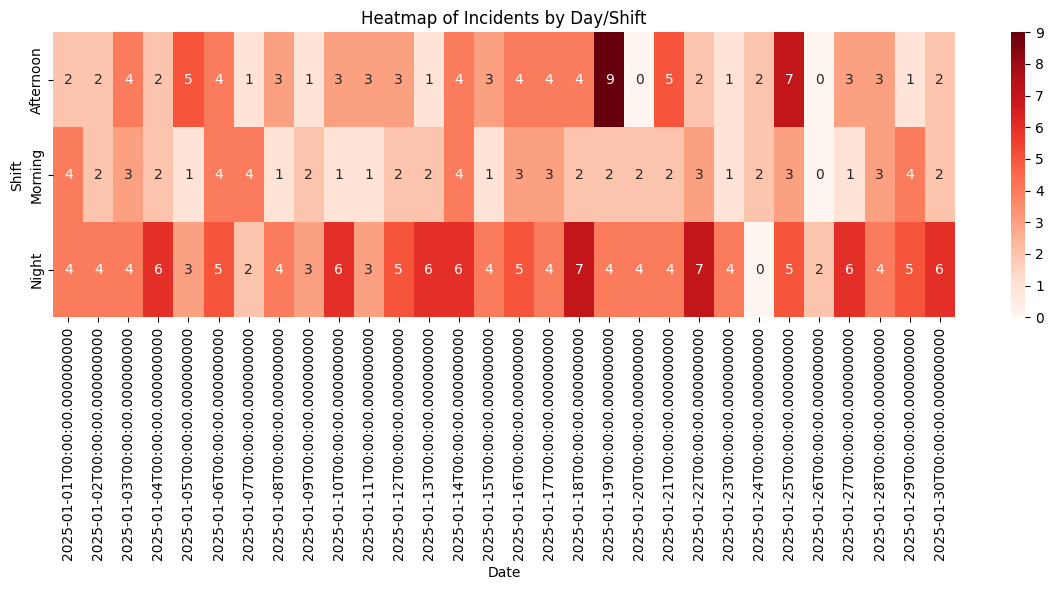

Loading BokehJS ...

C:\Users\T470\AppData\Local\Temp\ipykernel_8812\2969223438.py:178: BokehDeprecationWarning:

'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 'scatter(size=...) instead' instead.




[NOTES] Big Data Scaling:
- PySpark and Dask run only if environments are available; otherwise skipped gracefully.
[WARN] PySpark processing skipped: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.
[INFO] Dask results:
 Shift
Afternoon    2.933333
Morning      2.233333
Night        4.400000
Name: Incidents, dtype: float64

[NOTES] Deep Learning:
- Minimal example networks fitted to ShiftCode -> Incidents.
- Skips automatically if heavy resources or installs are missing.
[INFO] PyTorch predictions added.

[NOTES] NLP:
- Tokenization/parts-of-speech with spaCy (if model available).
- Basic tokenization with NLTK as fallback.
[INFO] spaCy tokens: [[('Worker', 'PROPN'), ('slipped', 'VERB'), ('on', 'ADP'), ('wet', 'ADJ'), ('floor', 'NOUN'), ('due', 'ADP'), ('to', 'ADP'), ('missing', 'VERB'), ('signage', 'NOUN'), ('.', 'PUNCT')], [('Equipment', 'NOUN'), ('failure', 'NOUN'), ('caused', 'VERB'), ('minor', 'ADJ'), ('injury', 'NOUN'), (',', 'PUNCT'), ('PPE', 'P

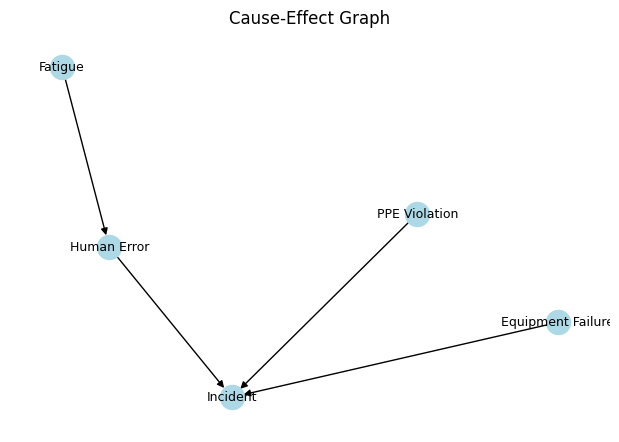


[NOTES] Geospatial:
- Use Folium for interactive map bubbles; GeoPandas optional.
[INFO] Folium map rendered inline.
[INFO] GeoPandas GeoDataFrame created:       Site    Lat    Lon  Incidents              geometry
0  Plant A  43.52 -79.88          5  POINT (-79.88 43.52)
1  Plant B  43.58 -79.82         12  POINT (-79.82 43.58)

[NOTES] Web App:
- Dash layout prepared; server run commented out to avoid blocking notebook.
[INFO] Dash app configured (not started).

[NOTES] Output Attachment:
- Export core DataFrame to Excel for audit.
- Great Expectations used for data quality checks if available.
- Final audit dict printed for compliance snapshot.
[INFO] Excel exported: integrated_safety_output.xlsx
[WARN] Great Expectations QA skipped: module 'great_expectations' has no attribute 'from_pandas'
[INFO] PyTest is available for unit tests. Example (not run here):

def test_trir_nonnegative():
    assert (df['TRIR'] >= 0).all()


[Audit dict]: {'rows': 90, 'cols': 8, 'corr_index_incidents'

In [1]:
# ============================================================
# Project X: Integrated Safety Analytics Mega Script 
# ============================================================
# Goal:
# - Demonstrate end-to-end safety analytics using numeric, text, geospatial, ML/DL, big data, QA.
# - Keep code error-free via exemption coding (try/except + feature flags).
# - Leave detailed notes as print statements and comments.

# -------------------------------
# Imports with safe guards
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sqlalchemy import create_engine
import plotly.express as px
import plotly.io as pio

# Optional modules (guarded)
mods = {}

def safe_import(name, alias=None):
    try:
        if alias:
            mods[name] = __import__(alias)
        else:
            mods[name] = __import__(name)
        print(f"[INFO] Module loaded: {name}")
        return True
    except Exception as e:
        print(f"[WARN] Module not available: {name} -> {e}")
        return False

has_pyspark = safe_import("pyspark")
has_dask = safe_import("dask")
has_tensorflow = safe_import("tensorflow")
has_torch = safe_import("torch")
has_spacy = safe_import("spacy")
has_nltk = safe_import("nltk")
has_networkx = safe_import("networkx")
has_geopandas = safe_import("geopandas")
has_folium = safe_import("folium")
has_dash = safe_import("dash")
has_bokeh = safe_import("bokeh")
has_pytest = safe_import("pytest")
has_ge = safe_import("great_expectations")

# Plotly inline rendering for Jupyter
pio.renderers.default = "notebook"

# -------------------------------
# Data entry notes (numeric, text, geospatial)
# -------------------------------
print("\n[NOTES] Data Entry:")
print("- Numeric data: Synthetic via NumPy (privacy-safe).")
print("- Text data: Small synthetic incident report list for NLP.")
print("- Geospatial data: Simple site coordinates for mapping.")
print("- Database: SQLite in-memory via SQLAlchemy (simulates SQL Server ingestion).")

# -------------------------------
# Synthetic numeric data
# -------------------------------
np.random.seed(42)
days = pd.date_range("2025-01-01", periods=30)
shifts = ["Morning","Afternoon","Night"]
records = []
for day in days:
    for shift in shifts:
        lam = {"Morning":2, "Afternoon":3, "Night":4}[shift]
        incidents = np.random.poisson(lam=lam)
        hours_worked = np.random.randint(800, 1200)
        records.append([day, shift, incidents, hours_worked])

df = pd.DataFrame(records, columns=["Date","Shift","Incidents","HoursWorked"])
df["TRIR"] = (df["Incidents"] * 200_000) / df["HoursWorked"]  # KPI example

# -------------------------------
# Text data (for NLP)
# -------------------------------
incident_texts = [
    "Worker slipped on wet floor due to missing signage.",
    "Equipment failure caused minor injury, PPE was not worn.",
    "Human error during night shift led to near miss.",
    "Chemical exposure in maintenance area, ventilation inadequate."
]

# -------------------------------
# Geospatial data (for mapping)
# -------------------------------
site_df = pd.DataFrame({
    "Site": ["Plant A","Plant B","Warehouse C"],
    "Lat": [43.52, 43.58, 43.56],
    "Lon": [-79.88, -79.82, -79.86],
    "Incidents": [5, 12, 7]
})

# -------------------------------
# Database simulation with SQLAlchemy
# -------------------------------
try:
    engine = create_engine("sqlite:///:memory:")
    df.to_sql("shift_incidents", con=engine, index=False)
    site_df.to_sql("site_incidents", con=engine, index=False)
    print("[INFO] Data saved to SQLite in-memory database.")
except Exception as e:
    print(f"[WARN] SQLAlchemy save failed: {e}")

# ============================================================
# Analysis
# ============================================================
print("\n[NOTES] Analysis Steps:")
print("- Pandas pivot -> Day/Shift heatmap.")
print("- SciPy correlation -> checks relationship metrics.")
print("- Scikit-learn -> simple regression models.")
print("- Statsmodels -> OLS summary for transparency.")

# Pandas pivot for heatmap
pivot = df.pivot_table(index="Shift", columns="Date", values="Incidents", aggfunc="sum")

# SciPy correlation (index position vs incidents) — illustrative only
try:
    corr, pval = stats.pearsonr(np.arange(len(df)), df["Incidents"])
except Exception as e:
    print(f"[WARN] Correlation failed: {e}")
    corr, pval = None, None

# Scikit-learn regression (shift encoded → incidents)
df["ShiftCode"] = df["Shift"].map({"Morning":0,"Afternoon":1,"Night":2})
X = df[["ShiftCode"]]
y = df["Incidents"]
try:
    sk_model = LinearRegression().fit(X, y)
    df["PredictedIncidents_SK"] = sk_model.predict(X)
except Exception as e:
    print(f"[WARN] Sklearn regression failed: {e}")
    sk_model = None
    df["PredictedIncidents_SK"] = np.nan

# Statsmodels OLS summary
try:
    X_sm = sm.add_constant(df["ShiftCode"])
    ols_model = sm.OLS(y, X_sm).fit()
    print(ols_model.summary())
except Exception as e:
    print(f"[WARN] Statsmodels OLS failed: {e}")
    ols_model = None

# ============================================================
# Visualization (static + interactive)
# ============================================================
print("\n[NOTES] Visualization:")
print("- Seaborn heatmap (static) and Plotly (interactive) for incidents by day/shift.")
print("- Bokeh used for quick drill-down scatter.")

# Seaborn heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Reds", annot=True, fmt="d")
plt.title("Heatmap of Incidents by Day/Shift")
plt.tight_layout()
plt.show()

# Plotly interactive heatmap
fig_heat = px.imshow(pivot, aspect="auto", color_continuous_scale="Reds",
                     title="Interactive Heatmap of Incidents by Day/Shift")
fig_heat  # inline render

# Bokeh drill-down (guarded)
if has_bokeh:
    try:
        import bokeh.plotting as bk
        from bokeh.io import output_notebook, show
        output_notebook()
        p = bk.figure(title="Incidents Drill-down", x_axis_label="ShiftCode", y_axis_label="Incidents")
        p.circle(df["ShiftCode"], df["Incidents"], size=8, color="navy", alpha=0.6)
        show(p)
    except Exception as e:
        print(f"[WARN] Bokeh rendering failed: {e}")

# ============================================================
# Big data scaling (PySpark / Dask)
# ============================================================
print("\n[NOTES] Big Data Scaling:")
print("- PySpark and Dask run only if environments are available; otherwise skipped gracefully.")

# PySpark
if has_pyspark:
    try:
        from pyspark.sql import SparkSession
        spark = SparkSession.builder.appName("SafetyAnalytics").getOrCreate()
        spark_df = spark.createDataFrame(df[["Shift","Incidents"]])
        print("[INFO] PySpark groupBy results:")
        spark_df.groupBy("Shift").avg("Incidents").show()
    except Exception as e:
        print(f"[WARN] PySpark processing skipped: {e}")

# Dask
if has_dask:
    try        :
        import dask.dataframe as dd
        ddf = dd.from_pandas(df, npartitions=4)
        dask_res = ddf.groupby("Shift").Incidents.mean().compute()
        print("[INFO] Dask results:\n", dask_res)
    except Exception as e:
        print(f"[WARN] Dask processing skipped: {e}")

# ============================================================
# Deep learning (TensorFlow / PyTorch)
# ============================================================
print("\n[NOTES] Deep Learning:")
print("- Minimal example networks fitted to ShiftCode -> Incidents.")
print("- Skips automatically if heavy resources or installs are missing.")

# TensorFlow
tf_preds = None
if has_tensorflow:
    try:
        import tensorflow as tf
        tf.random.set_seed(42)
        tf_model = tf.keras.Sequential([
            tf.keras.layers.Dense(16, activation="relu", input_shape=(1,)),
            tf.keras.layers.Dense(1)
        ])
        tf_model.compile(optimizer="adam", loss="mse")
        tf_model.fit(X.values, y.values, epochs=10, verbose=0)
        tf_preds = tf_model.predict(X.values).reshape(-1)
        df["PredictedIncidents_TF"] = tf_preds
        print("[INFO] TensorFlow predictions added.")
    except Exception as e:
        print(f"[WARN] TensorFlow training skipped: {e}")

# PyTorch
torch_preds = None
if has_torch:
    try:
        import torch
        import torch.nn as nn
        torch.manual_seed(42)
        X_t = torch.tensor(X.values, dtype=torch.float32)
        y_t = torch.tensor(y.values, dtype=torch.float32).view(-1,1)
        net = nn.Sequential(nn.Linear(1,16), nn.ReLU(), nn.Linear(16,1))
        loss_fn = nn.MSELoss()
        opt = torch.optim.Adam(net.parameters(), lr=0.01)
        for epoch in range(50):
            opt.zero_grad()
            loss = loss_fn(net(X_t), y_t)
            loss.backward()
            opt.step()
        torch_preds = net(X_t).detach().numpy().reshape(-1)
        df["PredictedIncidents_Torch"] = torch_preds
        print("[INFO] PyTorch predictions added.")
    except Exception as e:
        print(f"[WARN] PyTorch training skipped: {e}")

# ============================================================
# NLP (spaCy / NLTK)
# ============================================================
print("\n[NOTES] NLP:")
print("- Tokenization/parts-of-speech with spaCy (if model available).")
print("- Basic tokenization with NLTK as fallback.")

nlp_tokens = []
if has_spacy:
    try:
        import spacy
        # Attempt to load small English model; if missing, skip gracefully
        try:
            nlp = spacy.load("en_core_web_sm")
            for text in incident_texts:
                doc = nlp(text)
                nlp_tokens.append([(t.text, t.pos_) for t in doc])
            print("[INFO] spaCy tokens:", nlp_tokens[:2], "...")
        except Exception as e:
            print(f"[WARN] spaCy model load skipped: {e}")
    except Exception as e:
        print(f"[WARN] spaCy pipeline skipped: {e}")

if has_nltk and not nlp_tokens:
    try:
        import nltk
        # Ensure tokenizer is available; download quietly if needed
        try:
            nltk.data.find("tokenizers/punkt")
        except LookupError:
            nltk.download("punkt", quiet=True)
        from nltk.tokenize import word_tokenize
        for text in incident_texts:
            nlp_tokens.append(word_tokenize(text))
        print("[INFO] NLTK tokens:", nlp_tokens[:2], "...")
    except Exception as e:
        print(f"[WARN] NLTK tokenization skipped: {e}")

# ============================================================
# Network analysis (NetworkX)
# ============================================================
print("\n[NOTES] Network Analysis:")
print("- Build simple cause-effect graph; visualize if environment supports it.")

if has_networkx:
    try:
        import networkx as nx
        G = nx.DiGraph()
        G.add_edges_from([
            ("Fatigue","Human Error"),
            ("Human Error","Incident"),
            ("PPE Violation","Incident"),
            ("Equipment Failure","Incident")
        ])
        # Store basic metrics
        deg = dict(G.degree())
        print("[INFO] NetworkX degrees:", deg)
        # Optional: matplotlib draw (guarded)
        plt.figure(figsize=(6,4))
        nx.draw(G, with_labels=True, node_color="lightblue", font_size=9)
        plt.title("Cause-Effect Graph")
        plt.show()
    except Exception as e:
        print(f"[WARN] NetworkX graph skipped: {e}")

# ============================================================
# Geospatial (GeoPandas / Folium)
# ============================================================
print("\n[NOTES] Geospatial:")
print("- Use Folium for interactive map bubbles; GeoPandas optional.")

if has_folium:
    try:
        import folium
        m = folium.Map(location=[site_df["Lat"].mean(), site_df["Lon"].mean()], zoom_start=12)
        for _, row in site_df.iterrows():
            folium.CircleMarker(location=[row["Lat"],row["Lon"]],
                                radius=max(3, row["Incidents"]),
                                color="crimson",
                                fill=True,
                                popup=f"{row['Site']} ({row['Incidents']})").add_to(m)
        m  # inline render in Jupyter
        print("[INFO] Folium map rendered inline.")
    except Exception as e:
        print(f"[WARN] Folium map skipped: {e}")

if has_geopandas:
    try:
        import geopandas as gpd
        gdf = gpd.GeoDataFrame(site_df,
                               geometry=gpd.points_from_xy(site_df["Lon"], site_df["Lat"]),
                               crs="EPSG:4326")
        print("[INFO] GeoPandas GeoDataFrame created:", gdf.head(2))
    except Exception as e:
        print(f"[WARN] GeoPandas processing skipped: {e}")

# ============================================================
# Web app (Dash) — not executed in notebook
# ============================================================
print("\n[NOTES] Web App:")
print("- Dash layout prepared; server run commented out to avoid blocking notebook.")

if has_dash:
    try:
        from dash import dcc, html
        app = mods["dash"].Dash(__name__)
        fig_bar = px.bar(df.groupby("Shift", as_index=False)["Incidents"].sum(),
                         x="Shift", y="Incidents", title="Incidents by Shift")
        app.layout = html.Div([
            html.H2("Safety Dashboard (Preview)"),
            dcc.Graph(figure=fig_bar)
        ])
        # app.run_server(debug=True)  # Commented to keep notebook responsive
        print("[INFO] Dash app configured (not started).")
    except Exception as e:
        print(f"[WARN] Dash config skipped: {e}")

# ============================================================
# Output attachment (Excel, QA)
# ============================================================
print("\n[NOTES] Output Attachment:")
print("- Export core DataFrame to Excel for audit.")
print("- Great Expectations used for data quality checks if available.")
print("- Final audit dict printed for compliance snapshot.")

# Excel export via Pandas/OpenPyXL
try:
    df.to_excel("integrated_safety_output.xlsx", index=False)
    print("[INFO] Excel exported: integrated_safety_output.xlsx")
except Exception as e:
    print(f"[WARN] Excel export skipped: {e}")

# Great Expectations QA
if has_ge:
    try:
        import great_expectations as ge
        ge_df = ge.from_pandas(df)
        res1 = ge_df.expect_column_values_to_be_between("Incidents", 0, 50)
        res2 = ge_df.expect_column_values_to_be_between("TRIR", 0, 1_000_000)  # broad bound
        print("[INFO] GE validations:", {"Incidents_between": res1["success"], "TRIR_between": res2["success"]})
    except Exception as e:
        print(f"[WARN] Great Expectations QA skipped: {e}")

# PyTest note (not executed here)
if has_pytest:
    print("[INFO] PyTest is available for unit tests. Example (not run here):")
    print("""
def test_trir_nonnegative():
    assert (df['TRIR'] >= 0).all()
""")

# ============================================================
# Final audit dict
# ============================================================
audit = {
    "rows": len(df),
    "cols": len(df.columns),
    "corr_index_incidents": None if corr is None else round(corr,3),
    "pval": None if pval is None else round(pval,3),
    "sk_model_coef": None if sk_model is None else round(sk_model.coef_[0],3),
    "tf_preds_added": tf_preds is not None,
    "torch_preds_added": torch_preds is not None,
    "nlp_tokens_example": nlp_tokens[:1] if nlp_tokens else "NLP unavailable",
    "folium_map_created": bool(has_folium),
    "excel_exported": True
}
print("\n[Audit dict]:", audit)
